In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.6 MB/s eta 0:00:00


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imágenes encontradas: 13
Imagen: 9f9f257f-9_4.jpg


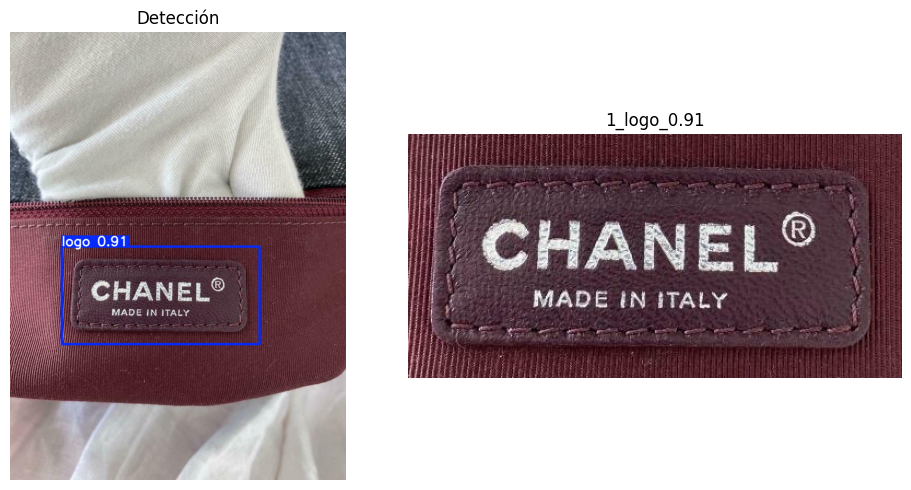

Imagen: 0bc6c291-2_62.jpg


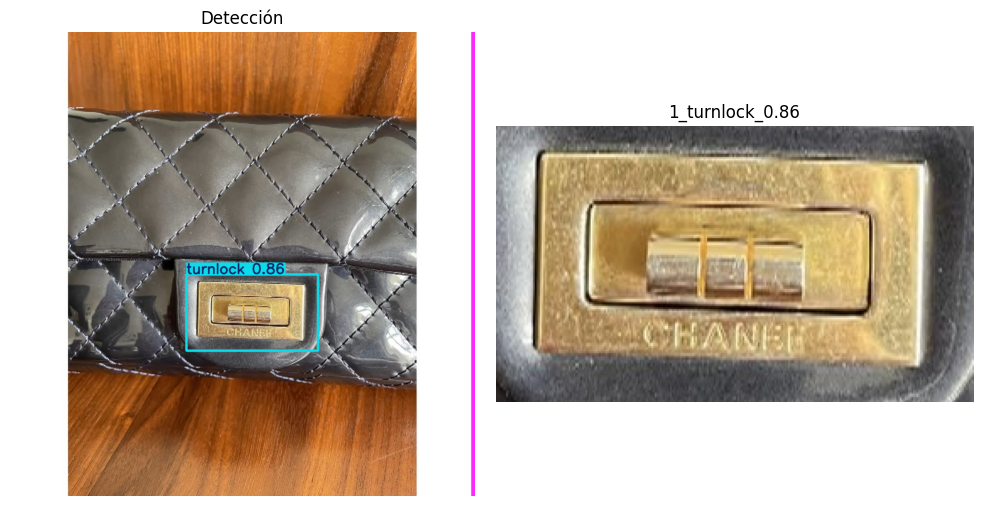

Imagen: 2a209cea-10_4.jpg


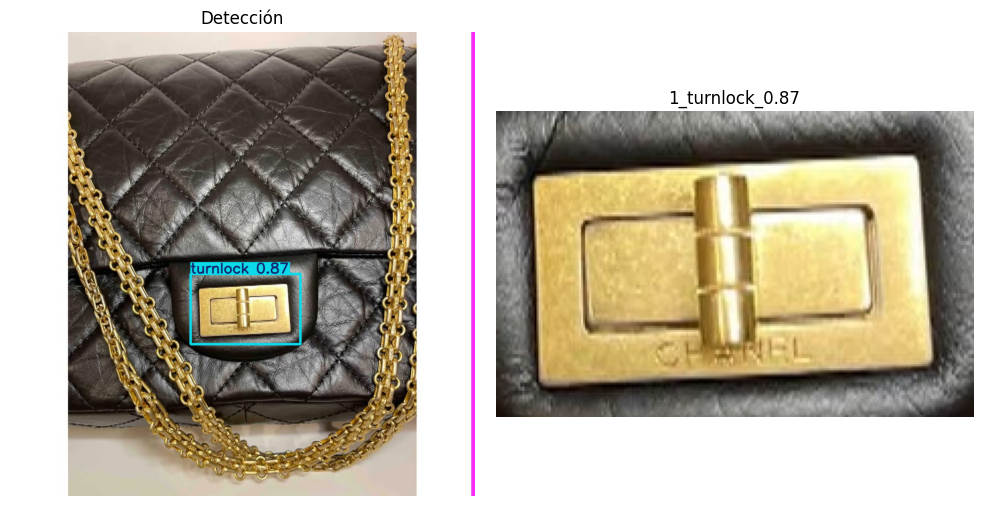

Imagen: 4d8b095f-3_7.jpg


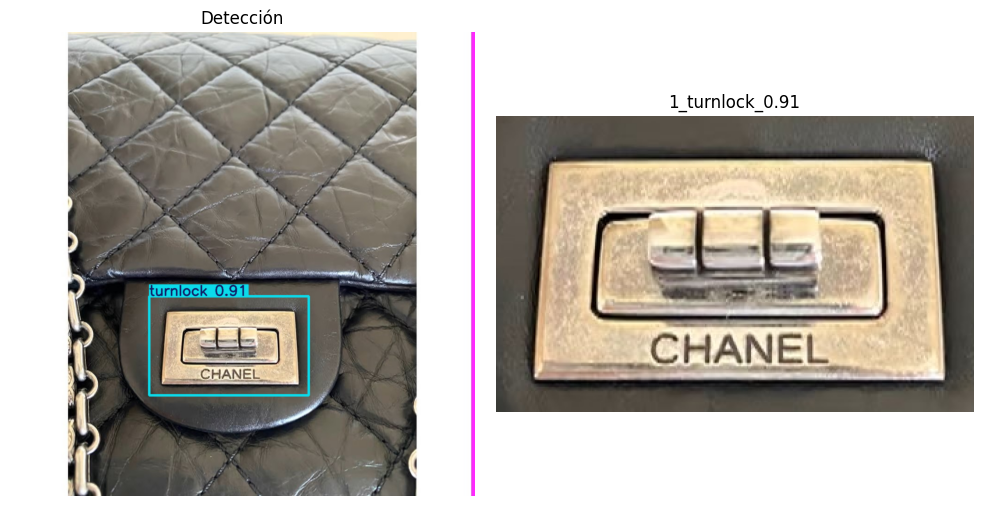

Imagen: 7f6dba66-1_168.jpg


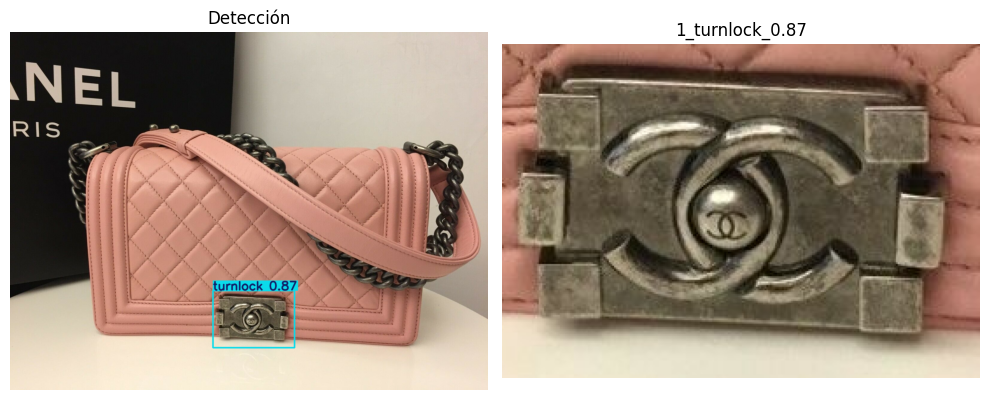

Imagen: 2df064eb-4_25.jpg


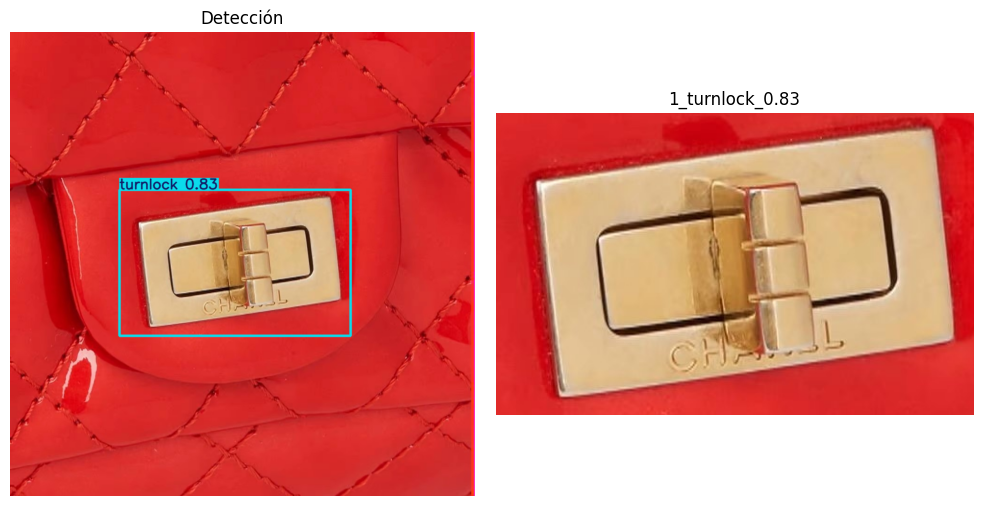

Imagen: 7b3b7eac-3_67.jpg


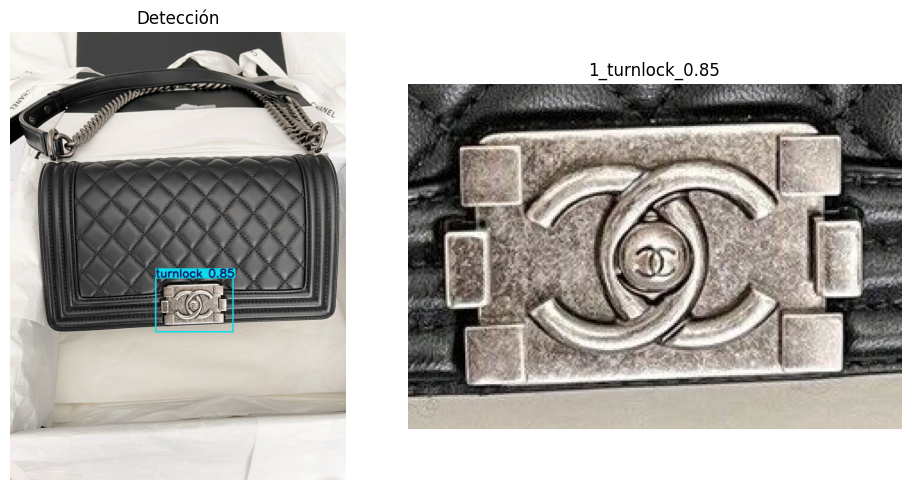

Imagen: 1cc48fc3-1_150.jpg


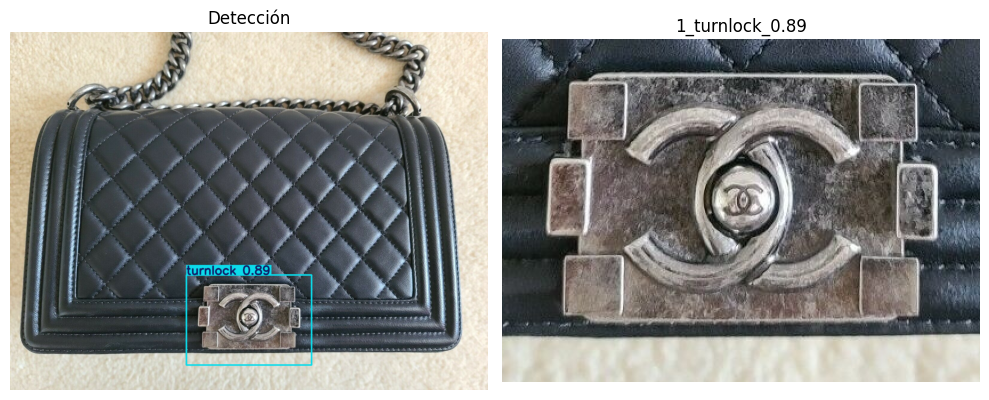

Imagen: 00ba969b-10_7.jpg


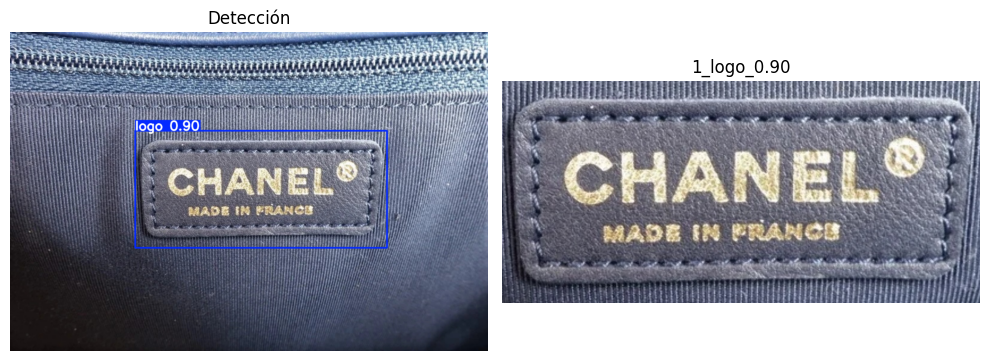

Imagen: 5cd68c11-1_86.jpg


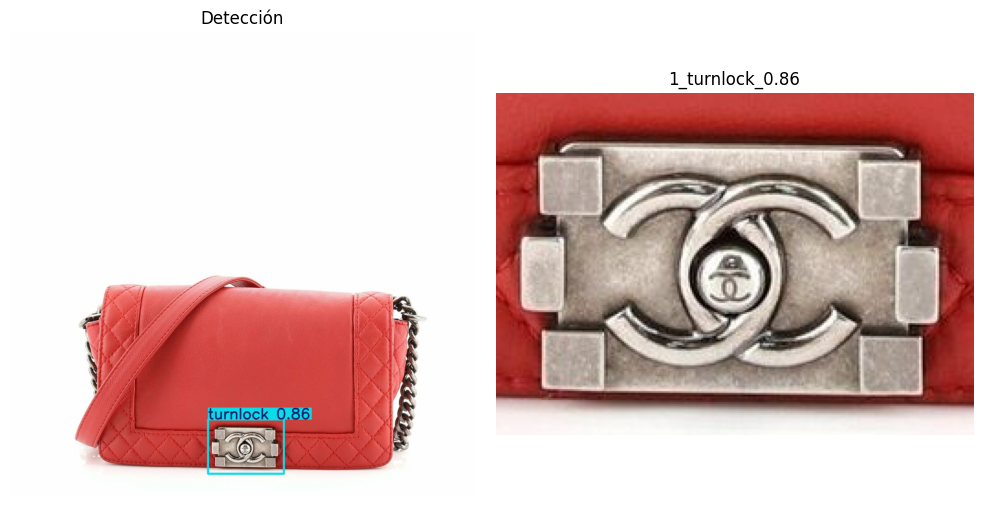

Imagen: 6cddce95-1_108.jpg


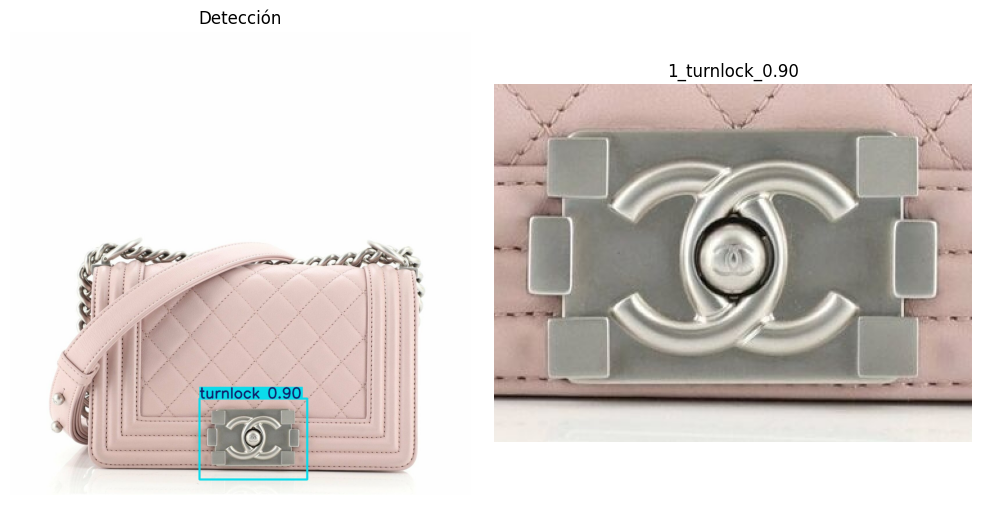

Imagen: 7fbb2d56-1_113.jpg


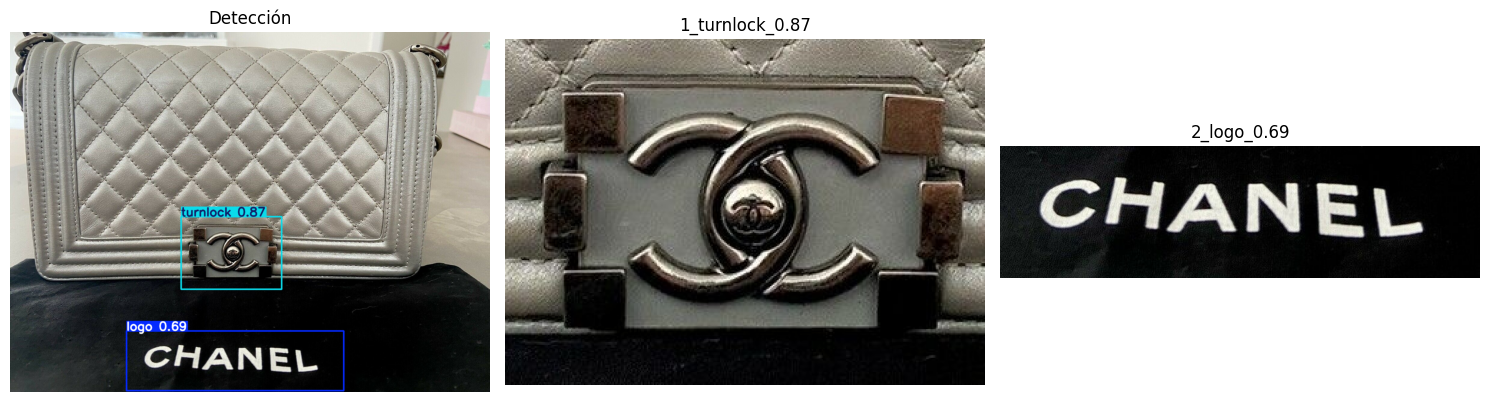

Imagen: 2a7dddec-9_aug_134.jpg


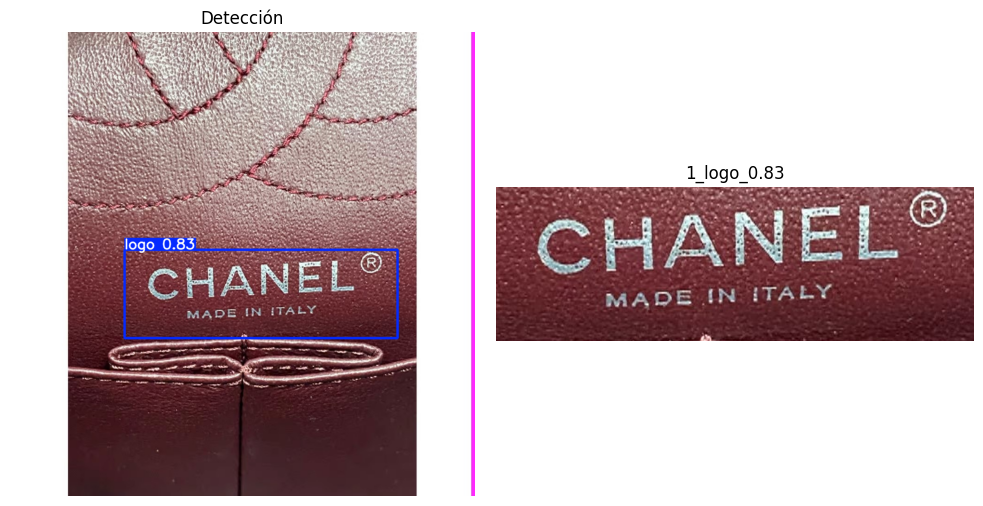

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import os, glob, cv2

MODEL_PATH = "/content/drive/MyDrive/PI_II/Ch_parts_v2/weights/best.pt"
DEMO_DIR = "/content/drive/MyDrive/PI_II/demo"

model = YOLO(MODEL_PATH)

image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
    image_paths.extend(glob.glob(os.path.join(DEMO_DIR, ext)))

print("Imágenes encontradas:", len(image_paths))

for img_path in image_paths:
    results = model.predict(
        source=img_path,
        conf=0.25,
        save=False,
        verbose=False
    )

    result = results[0]
    img = Image.open(img_path).convert("RGB")

    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    boxes = result.boxes
    crops = []

    if boxes is not None and len(boxes) > 0:
        for i, box in enumerate(boxes):
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = model.names[cls_id]

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

            crop = img.crop((x1, y1, x2, y2))
            crop_name = f"{i+1}_{class_name}_{conf:.2f}"
            crops.append((crop, crop_name))

    print("=" * 80)
    print("Imagen:", os.path.basename(img_path))

    total_cols = 1 + max(1, len(crops))
    plt.figure(figsize=(5 * total_cols, 5))

    plt.subplot(1, total_cols, 1)
    plt.imshow(plotted)
    plt.axis("off")
    plt.title("Detección")

    if len(crops) == 0:
        plt.subplot(1, total_cols, 2)
        plt.text(0.5, 0.5, "Sin detecciones", ha="center", va="center")
        plt.axis("off")
    else:
        for idx, (crop, crop_name) in enumerate(crops, start=2):
            plt.subplot(1, total_cols, idx)
            plt.imshow(crop)
            plt.axis("off")
            plt.title(crop_name)

    plt.tight_layout()
    plt.show()